## 📄 Dataset Feature Descriptions

1. **Y** – Latitude coordinate of the observation station.  
2. **X** – Longitude coordinate of the observation station.  
3. **data_payload_id** – Unique identifier for the data record.  
4. **instance_datetime** – Timestamp when the data was recorded.  
5. **url** – URL reference to the data source.  
6. **agency** – Organization responsible for the data.  
7. **platform_type** – Type of platform (e.g., station, balloon, etc.).  
8. **platform_id** – Numeric ID for the platform.  
9. **platform_name** – Name of the observation platform or station.  
10. **gaw_id** – Global Atmosphere Watch ID of the platform.  
11. **instrument_name** – Name of the instrument used for measurement.  
12. **instrument_model** – Model of the instrument.  
13. **instrument_number** – Instrument's identification number.  
14. **monthly_date** – Date associated with monthly aggregated data.  
15. **monthly_columno3** – Monthly average ozone column value.  
16. **monthly_stddevo3** – Standard deviation of the monthly ozone values.  
17. **monthly_npts** – Number of observations used in monthly average.  
18. **daily_date** – Date of the daily observation.  
19. **daily_wlcode** – Wavelength code used during observation.  
20. **daily_obscode** – Observation code (e.g., method or technique).  
21. **daily_columno3** – Daily ozone column measurement (Dobson Units).  
22. **daily_stddevo3** – Standard deviation of the daily ozone value.  
23. **daily_utc_begin** – UTC time when observation began.  
24. **daily_utc_end** – UTC time when observation ended.  
25. **daily_utc_mean** – Mean UTC time of observation.  
26. **daily_nobs** – Number of observations for that day.  
27. **daily_mmu** – Measurement uncertainty for daily ozone.  
28. **daily_columnso2** – Daily SO₂ (sulfur dioxide) column measurement.  
29. **latest_observation** – Flag indicating if this is the most recent data (0 or 1).  
30. **country** – Country of the observation station.  
31. **scientific_authority** – Name of the responsible scientist or authority.  
32. **version** – Version number of the data record.


**Combining  8 Countries Datasets**
<br>
<ol>
<li>Argentina</li>
<li>Brazil</li>
<li>Canada</li>
<li>Chile</li>
<li>Greenland</li>
<li>Mexico</li>
<li>Peru</li>
<li>USA</li>
</ol>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import optuna
from optuna.samplers import TPESampler
import plotly.express as px
import plotly.graph_objects as go


**Visualization**

In [9]:
df1=pd.read_csv('combined_dataset/totalozone_ARG.csv')
df2=pd.read_csv('combined_dataset/totalozone_BRA.csv')
df3=pd.read_csv('combined_dataset/totalozone_CAN.csv')
df4=pd.read_csv('combined_dataset/totalozone_CHL.csv')
df5=pd.read_csv('combined_dataset/totalozone_GRL.csv')
df6=pd.read_csv('combined_dataset/totalozone_MEX.csv')
df7=pd.read_csv('combined_dataset/totalozone_PER.csv')
df8=pd.read_csv('combined_dataset/totalozone_USA.csv')
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df['daily_date'] = pd.to_datetime(df['daily_date'], format='%Y-%m-%d')
df.head()


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (21,26) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22,25,26,27) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns

,x,y,identifier,file_path,dataset_id,station_id,station_name,station_gaw_id,station_gaw_url,contributor_name,...,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,monthly_date,monthly_columno3,monthly_stdevo3,monthly_npts,url
0,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.800,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...
1,-68.310,-54.850,Dobson:Beck:131:TotalOzone_1.0:339:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,339,Ushuaia,USH,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,17.5,17.5,1.0,2.976,NaN,2025-04-30T00:00:00Z,277.0,27.7,30.0,https://woudc.org/archive/Archive-NewFormat/To...
2,-67.500,-45.783,Dobson:Beck:133:TotalOzone_1.0:342:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,342,Comodoro Rivadavia Aero,CMR,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,16.0,NaN,8.0,2.300,NaN,2025-04-30T00:00:00Z,263.4,21.7,28.0,https://woudc.org/archive/Archive-NewFormat/To...
3,-65.438,-22.111,Dobson:Beck:97:TotalOzone_1.0:513:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,513,La Quiaca,LQO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,3.0,1.500,NaN,2025-04-30T00:00:00Z,254.1,3.5,25.0,https://woudc.org/archive/Archive-NewFormat/To...
4,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.700,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...


**Area Chart of Year Vs Ozone**

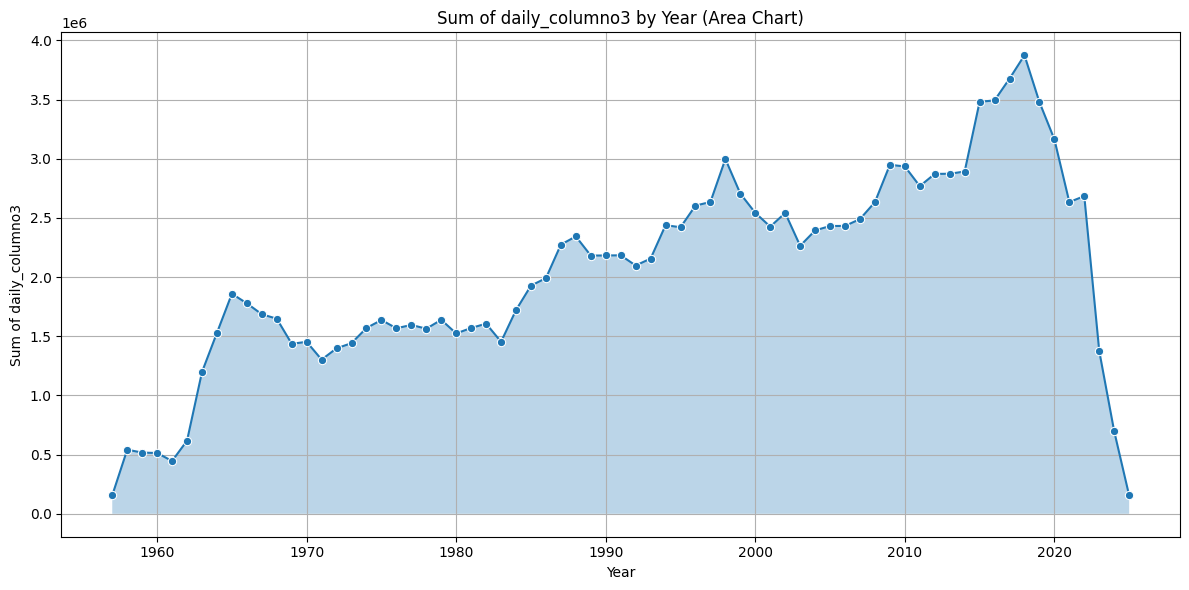

In [4]:
df['year'] = pd.to_numeric(df['daily_date'].dt.year, errors='coerce')

plt.figure(figsize=(12, 6))
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_yearly, x='year', y='daily_columno3', marker='o')
plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
plt.title('Sum of daily_columno3 by Year (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Bar Chart of Year Vs Ozone (After and Before 1989)**

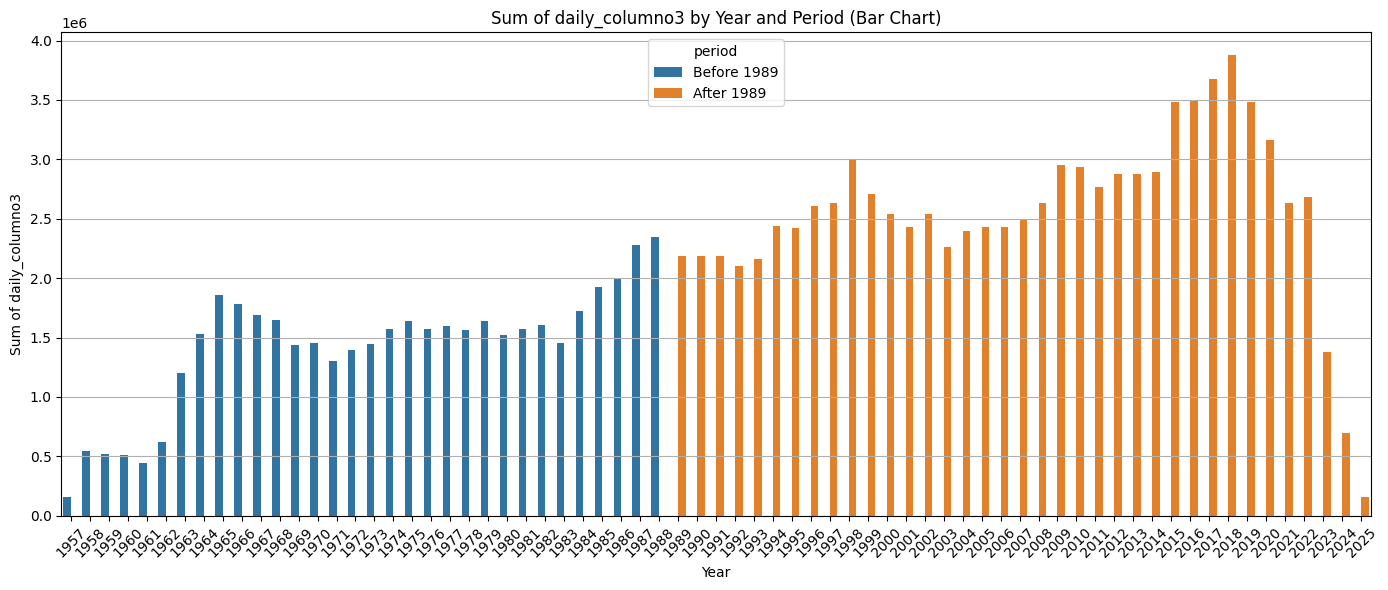

In [5]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')

# Group by year and period
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_period, x='year', y='daily_columno3', hue='period', dodge=True)

plt.title('Sum of daily_columno3 by Year and Period (Bar Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Bar Chart of Year Vs Ozone**

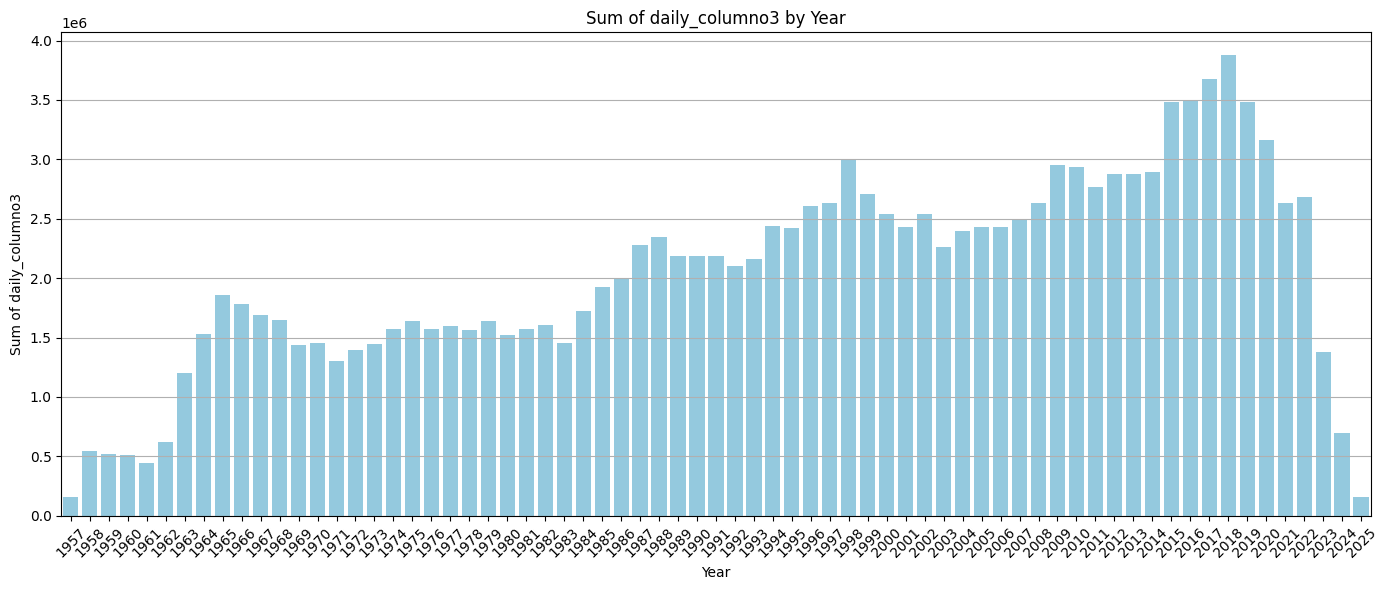

In [6]:
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_yearly, x='year', y='daily_columno3', color='skyblue')

plt.title('Sum of daily_columno3 by Year')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Line chart Year vs ozone (before and after 1989)**

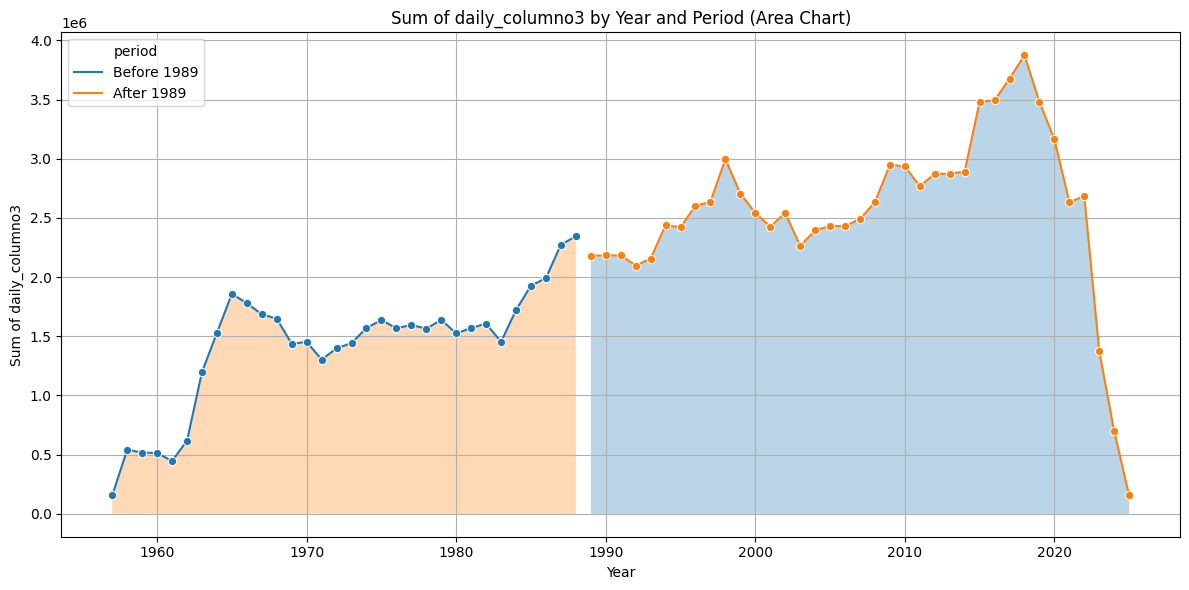

In [7]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')
plt.figure(figsize=(12, 6))
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_period, x='year', y='daily_columno3', hue='period', marker='o')
for period, group in df_period.groupby('period'):
    plt.fill_between(group['year'], group['daily_columno3'], alpha=0.3, label=f"{period} (area)")
plt.title('Sum of daily_columno3 by Year and Period (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Country wise year vs ozone**

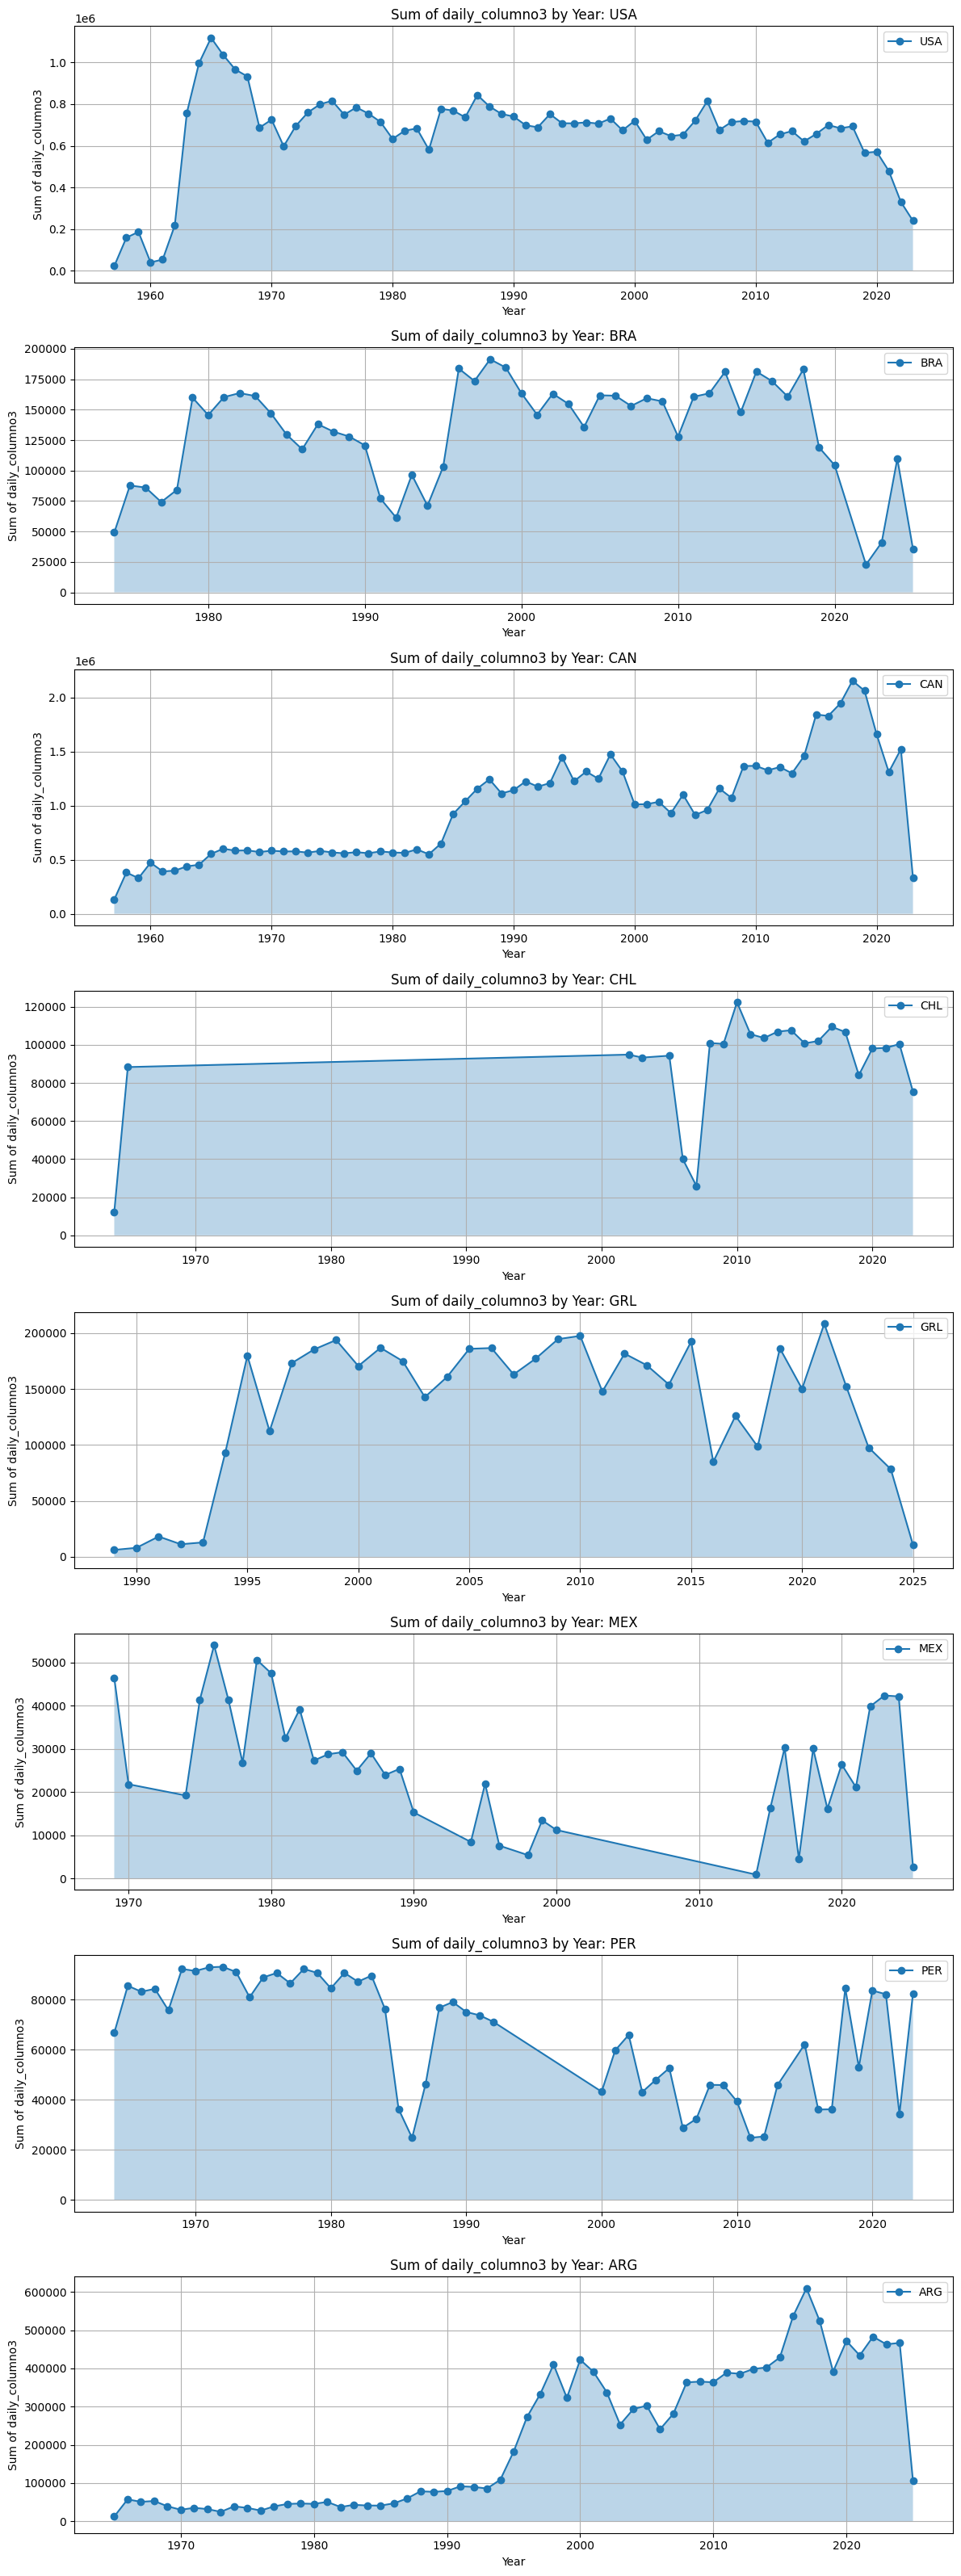

In [8]:
countries = ['USA', 'BRA', 'CAN', 'CHL', 'GRL', 'MEX', 'PER','ARG']
6
plt.figure(figsize=(12,4 * len(countries)))
for idx, country in enumerate(countries, 1):
    plt.subplot(len(countries), 1, idx)
    df_country = df[df['country_id'] == country]
    df_yearly = df_country.groupby('year')['daily_columno3'].sum().reset_index()
    plt.plot(df_yearly['year'], df_yearly['daily_columno3'], marker='o', label=country)
    plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
    plt.title(f'Sum of daily_columno3 by Year: {country}')
    plt.ylabel('Sum of daily_columno3')
    plt.xlabel('Year')
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.show()


**Specific Country wise model check**

In [13]:
# Filter rows where 'country' column is 'USA'
usa_df = df[df['country_id'] == 'USA'].copy()
can_df = df[df['country_id'] == 'CAN'].copy()
bra_df = df[df['country_id'] == 'BRA'].copy()
arg_df = df[df['country_id'] == 'ARG'].copy()
chl_df = df[df['country_id'] == 'CHL'].copy()
grl_df = df[df['country_id'] == 'GRL'].copy()
mex_df = df[df['country_id'] == 'MEX'].copy()
per_df = df[df['country_id'] == 'PER'].copy()
print("Shape of DataFrames for each country:")
print(usa_df.shape)
print(can_df.shape)
print(bra_df.shape)
print(arg_df.shape)
print(chl_df.shape)
print(grl_df.shape)
print(mex_df.shape)
print(per_df.shape)




Shape of DataFrames for each country:
(140695, 36)
(187033, 36)
(24865, 36)
(45720, 36)
(6898, 36)
(14498, 36)
(3615, 36)
(13811, 36)


In [14]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url'
]
usa_df.drop(columns=columns, inplace=True)
can_df.drop(columns=columns, inplace=True)
bra_df.drop(columns=columns, inplace=True)
arg_df.drop(columns=columns, inplace=True)
chl_df.drop(columns=columns, inplace=True)
grl_df.drop(columns=columns, inplace=True)
mex_df.drop(columns=columns, inplace=True)
per_df.drop(columns=columns, inplace=True)

usa_df = usa_df.groupby('daily_date').mean(numeric_only=True).reset_index()
usa_df = usa_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
usa_df.dropna(subset=['daily_columno3'], inplace=True)

can_df = can_df.groupby('daily_date').mean(numeric_only=True).reset_index()
can_df = can_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
can_df.dropna(subset=['daily_columno3'], inplace=True)

bra_df = bra_df.groupby('daily_date').mean(numeric_only=True).reset_index()
bra_df = bra_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
bra_df.dropna(subset=['daily_columno3'], inplace=True)

arg_df = arg_df.groupby('daily_date').mean(numeric_only=True).reset_index()
arg_df = arg_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
arg_df.dropna(subset=['daily_columno3'], inplace=True)

chl_df = chl_df.groupby('daily_date').mean(numeric_only=True).reset_index()
chl_df = chl_df.sort_values('daily_date', ascending=True).reset_index(drop=True)    
chl_df.dropna(subset=['daily_columno3'], inplace=True)

grl_df = grl_df.groupby('daily_date').mean(numeric_only=True).reset_index()
grl_df = grl_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
grl_df.dropna(subset=['daily_columno3'], inplace=True)

mex_df = mex_df.groupby('daily_date').mean(numeric_only=True).reset_index()
mex_df = mex_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
mex_df.dropna(subset=['daily_columno3'], inplace=True)

per_df = per_df.groupby('daily_date').mean(numeric_only=True).reset_index()
per_df = per_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
per_df.dropna(subset=['daily_columno3'], inplace=True)

usa_df['rolling_avg'] = usa_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
usa_df['rolling_std'] = usa_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
usa_df['ewm_avg'] = usa_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
usa_df['ewm_std'] = usa_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  usa_df[f'lag{i}'] = usa_df['daily_columno3'].shift(i)

usa_df.dropna(inplace=True)

can_df['rolling_avg'] = can_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
can_df['rolling_std'] = can_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
can_df['ewm_avg'] = can_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
can_df['ewm_std'] = can_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    can_df[f'lag{i}'] = can_df['daily_columno3'].shift(i)
can_df.dropna(inplace=True)


bra_df['rolling_avg'] = bra_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
bra_df['rolling_std'] = bra_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
bra_df['ewm_avg'] = bra_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
bra_df['ewm_std'] = bra_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    bra_df[f'lag{i}'] = bra_df['daily_columno3'].shift(i)
bra_df.dropna(inplace=True)


arg_df['rolling_avg'] = arg_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
arg_df['rolling_std'] = arg_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
arg_df['ewm_avg'] = arg_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
arg_df['ewm_std'] = arg_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    arg_df[f'lag{i}'] = arg_df['daily_columno3'].shift(i)
arg_df.dropna(inplace=True)


chl_df['rolling_avg'] = chl_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
chl_df['rolling_std'] = chl_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
chl_df['ewm_avg'] = chl_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()

chl_df['ewm_std'] = chl_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    chl_df[f'lag{i}'] = chl_df['daily_columno3'].shift(i)
chl_df.dropna(inplace=True)


chl_df.head()
grl_df['rolling_avg'] = grl_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
grl_df['rolling_std'] = grl_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
grl_df['ewm_avg'] = grl_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
grl_df['ewm_std'] = grl_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    grl_df[f'lag{i}'] = grl_df['daily_columno3'].shift(i)

grl_df.dropna(inplace=True)


mex_df['rolling_avg'] = mex_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
mex_df['rolling_std'] = mex_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
mex_df['ewm_avg'] = mex_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
mex_df['ewm_std'] = mex_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    mex_df[f'lag{i}'] = mex_df['daily_columno3'].shift(i)
mex_df.dropna(inplace=True)

per_df['rolling_avg'] = per_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
per_df['rolling_std'] = per_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
per_df['ewm_avg'] = per_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
per_df['ewm_std'] = per_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    per_df[f'lag{i}'] = per_df['daily_columno3'].shift(i)
per_df.dropna(inplace=True)

print("Final shapes of DataFrames after processing:")
print(usa_df.shape)
print(can_df.shape)
print(bra_df.shape)
print(arg_df.shape)
print(chl_df.shape)
print(grl_df.shape)
print(mex_df.shape)
print(per_df.shape)


Final shapes of DataFrames after processing:
(23624, 21)
(24022, 21)
(15686, 21)
(16244, 21)
(6883, 21)
(9036, 21)
(3600, 21)
(13796, 21)


In [15]:


# Define list of DataFrames and corresponding country names
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'CHL': chl_df,
    'GRL': grl_df,
    'MEX': mex_df,
    'PER': per_df
}

# Define features to use in the model
features = ['rolling_avg', 'rolling_std', 'ewm_avg', 'ewm_std'] + [f'lag{i}' for i in range(1, 16)]

# Store results
eval_results = []

for country, df in country_dfs.items():
    print(f"\n🇨🇴 Running model for: {country}")
    
    # Prepare X and y
    X = df[features]
    y = df['daily_columno3']
    
    # Train-test split (80% train, 20% test)
    split_index = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")
    
    # Save to results
    eval_results.append({
        'Country': country,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2*100
    })

# Convert results to DataFrame
results_df = pd.DataFrame(eval_results).sort_values('RMSE')
print("\n📊 Evaluation Summary (sorted by RMSE):")
print(results_df)




🇨🇴 Running model for: USA
✅ RMSE: 13.42, MAE: 9.48, R²: 0.78

🇨🇴 Running model for: CAN
✅ RMSE: 13.80, MAE: 9.85, R²: 0.88

🇨🇴 Running model for: BRA
✅ RMSE: 11.14, MAE: 4.79, R²: 0.44

🇨🇴 Running model for: ARG
✅ RMSE: 13.19, MAE: 10.03, R²: 0.70

🇨🇴 Running model for: CHL
✅ RMSE: 24.62, MAE: 18.74, R²: 0.48

🇨🇴 Running model for: GRL
✅ RMSE: 21.06, MAE: 14.69, R²: 0.83

🇨🇴 Running model for: MEX
✅ RMSE: 6.69, MAE: 5.24, R²: 0.85

🇨🇴 Running model for: PER
✅ RMSE: 3.26, MAE: 2.45, R²: 0.59

📊 Evaluation Summary (sorted by RMSE):
  Country       RMSE        MAE         R2
7     PER   3.260867   2.454376  59.193544
6     MEX   6.686586   5.241951  85.061436
2     BRA  11.138790   4.790635  43.949811
3     ARG  13.193982  10.028709  70.123976
0     USA  13.421484   9.483934  77.913642
1     CAN  13.804747   9.848221  88.241067
5     GRL  21.057892  14.692456  83.232893
4     CHL  24.619596  18.737699  47.544707


***Generic All Country Model Check**

**Pre-Processing**

**Droping Other Unnecessary Columns**

In [9]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url'
]
df.drop(columns=columns, inplace=True)

df.head()

,daily_date,daily_columno3,year,period
0,2025-04-30 00:00:00+00:00,264.0,2025,After 1989
1,2025-04-30 00:00:00+00:00,327.0,2025,After 1989
2,2025-04-30 00:00:00+00:00,256.0,2025,After 1989
3,2025-04-30 00:00:00+00:00,255.0,2025,After 1989
4,2025-04-29 00:00:00+00:00,265.0,2025,After 1989


**Grouping Values with same date-time**

In [10]:
print(f"Shape before dropping NaN values: {df.shape}")

Shape before dropping NaN values: (437135, 4)


In [11]:
df = df.groupby('daily_date').mean(numeric_only=True).reset_index()
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)
df.dropna(subset=['daily_columno3'], inplace=True)

df.head()

,daily_date,daily_columno3,year
0,1957-07-01 00:00:00+00:00,337.766667,1957
1,1957-07-02 00:00:00+00:00,303.966667,1957
2,1957-07-03 00:00:00+00:00,322.500000,1957
3,1957-07-04 00:00:00+00:00,322.500000,1957
4,1957-07-05 00:00:00+00:00,317.966667,1957


In [12]:
print(F"Shape after dropping NaN values: {df.shape}")

Shape after dropping NaN values: (24745, 3)


**Spliting and scalling data**

In [13]:
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()

(24730, 22)


,daily_date,daily_columno3,year,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,...,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
15,1957-07-16 00:00:00+00:00,335.94,1957,330.374167,5.969687,328.764897,6.688511,329.88,322.45,330.525,...,335.180,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667,337.766667
16,1957-07-17 00:00:00+00:00,328.16,1957,331.261500,6.081848,330.124281,6.711755,335.94,329.88,322.450,...,339.640,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667
17,1957-07-18 00:00:00+00:00,318.60,1957,330.097500,5.334002,329.754953,6.096926,328.16,335.94,329.880,...,327.400,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000
18,1957-07-19 00:00:00+00:00,315.88,1957,329.384167,6.360663,327.670509,7.163891,318.60,328.16,335.940,...,330.525,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000
19,1957-07-20 00:00:00+00:00,310.10,1957,328.365500,7.638370,325.478361,8.076394,315.88,318.60,328.160,...,322.450,330.525000,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667


In [14]:
lag_features = [f'lag{i}' for i in range(1, 16)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

minmax_x = MinMaxScaler()
minmax_y = MinMaxScaler()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scale the features
X_train= minmax_x.fit_transform(X_train)
X_test= minmax_x.transform(X_test)
# Scale the target variable
y_train= minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test= minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

**Training Models**

In [15]:


# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.035
MAE : 0.026
R2  : 87.28 %

----- Decision Tree -----
RMSE: 0.051
MAE : 0.038
R2  : 73.05 %

----- Random Forest -----
RMSE: 0.036
MAE : 0.026
R2  : 86.66 %

----- Gradient Boosting -----
RMSE: 0.035
MAE : 0.026
R2  : 87.23 %

----- Support Vector Regressor -----
RMSE: 0.042
MAE : 0.032
R2  : 82.16 %

----- AdaBoost Regressor -----
RMSE: 0.042
MAE : 0.033
R2  : 81.46 %

----- MLP Regressor -----
RMSE: 0.036
MAE : 0.027
R2  : 86.36 %

----- K-Neighbors Regressor -----
RMSE: 0.042
MAE : 0.031
R2  : 82.08 %



**Parameter Tuning**

In [16]:

param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# ----------- STEP 4: Models Dictionary ----------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# ----------- STEP 5: Suggestion Utility ----------- #
def suggest(trial, name, dist):
    if isinstance(dist, tuple) and dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# ----------- STEP 6: Model Tuning Function ----------- #
def tune_model(name, model_class, param_space, n_trials=10):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = mean_squared_error(y_test, preds)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    print(f"{name} Best Params: {study.best_params}")
    return model_class(**study.best_params)

# ----------- STEP 7: Tuning and Evaluation ----------- #
results = {}
best_models = {}

for name in model_classes:
    print(f"\nTuning {name}...")
    model = tune_model(name, model_classes[name], param_spaces.get(name, {}), n_trials=20)
    model.fit(X_train, y_train)
    best_models[name] = model

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Predictions': preds,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# ----------- STEP 8: Print Metrics ----------- #
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2'] * 100):.2f} %\n")



[I 2025-06-12 15:57:32,538] A new study created in memory with name: no-name-278c3e20-465f-4603-bdeb-569bd1708ba4



Tuning Linear Regression...

Tuning Decision Tree...


[I 2025-06-12 15:57:32,710] Trial 0 finished with value: 0.0013381008040171591 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.0013381008040171591.
[I 2025-06-12 15:57:32,975] Trial 1 finished with value: 0.001427801921906433 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.0013381008040171591.
[I 2025-06-12 15:57:33,125] Trial 2 finished with value: 0.001432164073867715 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.0013381008040171591.
[I 2025-06-12 15:57:33,259] Trial 3 finished with value: 0.0016710631654570155 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.0013381008040171591.
[I 2025-06-12 15:57:33,492] Trial 4 finished with value: 0.0013680517628734514 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.0013381008040171591.
[I 2025-06-12 15:57:33,591] Trial 5 finished with value: 0.00

Decision Tree Best Params: {'max_depth': 6, 'min_samples_split': 5}

Tuning Random Forest...



[I 2025-06-12 15:57:55,905] Trial 0 finished with value: 0.0012528284977658462 and parameters: {'n_estimators': 106, 'max_depth': 10}. Best is trial 0 with value: 0.0012528284977658462.
[I 2025-06-12 15:58:16,804] Trial 1 finished with value: 0.0012436495200360243 and parameters: {'n_estimators': 160, 'max_depth': 7}. Best is trial 1 with value: 0.0012436495200360243.
[I 2025-06-12 15:58:22,610] Trial 2 finished with value: 0.0013347012849511419 and parameters: {'n_estimators': 73, 'max_depth': 4}. Best is trial 1 with value: 0.0012436495200360243.
[I 2025-06-12 15:58:31,686] Trial 3 finished with value: 0.0012468067887908092 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.0012436495200360243.
[I 2025-06-12 15:58:52,187] Trial 4 finished with value: 0.001247055186224056 and parameters: {'n_estimators': 140, 'max_depth': 8}. Best is trial 1 with value: 0.0012436495200360243.
[I 2025-06-12 15:59:01,431] Trial 5 finished with value: 0.00125695944819175

...

MLP Regressor Best Params: {'hidden_layer_sizes': (100,), 'alpha': 0.001205152228495674, 'learning_rate_init': 0.007936602089465884}


[I 2025-06-12 16:20:17,302] A new study created in memory with name: no-name-9b6b78ce-01f9-4779-a314-5033bc9eaccb



Tuning K-Neighbors Regressor...


[I 2025-06-12 16:20:18,705] Trial 0 finished with value: 0.0015791595538751184 and parameters: {'n_neighbors': 5}. Best is trial 0 with value: 0.0015791595538751184.
[I 2025-06-12 16:20:20,096] Trial 1 finished with value: 0.0014741774261432126 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 16:20:21,472] Trial 2 finished with value: 0.0014972380918088762 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 16:20:22,781] Trial 3 finished with value: 0.0015111826630972683 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 16:20:24,218] Trial 4 finished with value: 0.0017341733109333228 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0014741774261432126.
[I 2025-06-12 16:20:25,609] Trial 5 finished with value: 0.0017341733109333228 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0014741774261432126.
[I 

K-Neighbors Regressor Best Params: {'n_neighbors': 10}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.035
MAE : 0.026
R2  : 87.28 %

----- Decision Tree -----
RMSE: 0.036
MAE : 0.027
R2  : 86.27 %

----- Random Forest -----
RMSE: 0.035
MAE : 0.026
R2  : 87.11 %

----- Gradient Boosting -----
RMSE: 0.035
MAE : 0.026
R2  : 87.23 %

----- SVR -----
RMSE: 0.037
MAE : 0.027
R2  : 85.78 %

----- AdaBoost Regressor -----
RMSE: 0.038
MAE : 0.029
R2  : 84.71 %

----- MLP Regressor -----
RMSE: 0.035
MAE : 0.026
R2  : 87.16 %

----- K-Neighbors Regressor -----
RMSE: 0.038
MAE : 0.029
R2  : 84.77 %



**Predicted value vs Actual value**

In [17]:
# Number of rows to display
n_display = 10

print("\n--- Actual vs Predicted on Test Set (Top 10 Rows) ---\n")
for name, res in results.items():
    print(f"--- {name} ---")
    comparison = pd.DataFrame({
        'Actual': y_test[:n_display],
        'Predicted': res['Predictions'][:n_display]

    })
    print(comparison.round(3))
    print("\n")



--- Actual vs Predicted on Test Set (Top 10 Rows) ---

--- Linear Regression ---
   Actual  Predicted
0   0.187      0.173
1   0.203      0.183
2   0.208      0.196
3   0.176      0.203
4   0.179      0.183
5   0.193      0.185
6   0.187      0.192
7   0.169      0.187
8   0.157      0.177
9   0.116      0.166


--- Decision Tree ---
   Actual  Predicted
0   0.187      0.180
1   0.203      0.193
2   0.208      0.203
3   0.176      0.203
4   0.179      0.180
5   0.193      0.180
6   0.187      0.193
7   0.169      0.193
8   0.157      0.180
9   0.116      0.166


--- Random Forest ---
   Actual  Predicted
0   0.187      0.177
1   0.203      0.187
2   0.208      0.199
3   0.176      0.205
4   0.179      0.179
5   0.193      0.181
6   0.187      0.196
7   0.169      0.187
8   0.157      0.177
9   0.116      0.163


--- Gradient Boosting ---
   Actual  Predicted
0   0.187      0.177
1   0.203      0.188
2   0.208      0.197
3   0.176      0.202
4   0.179      0.179
5   0.193      0.181
6 

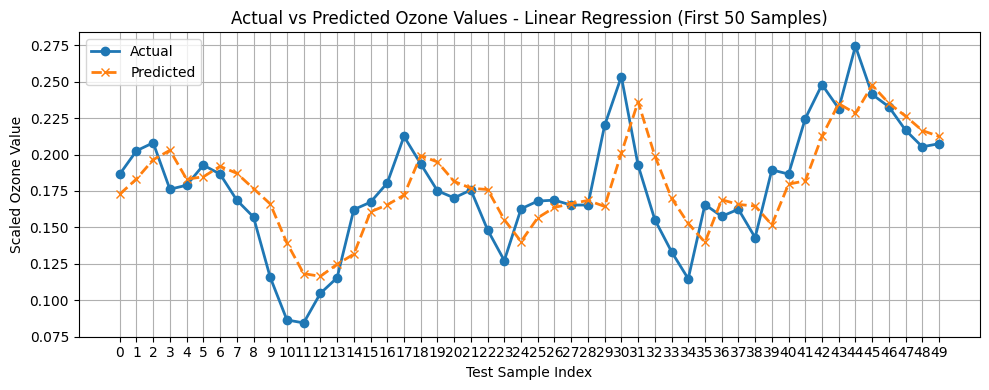

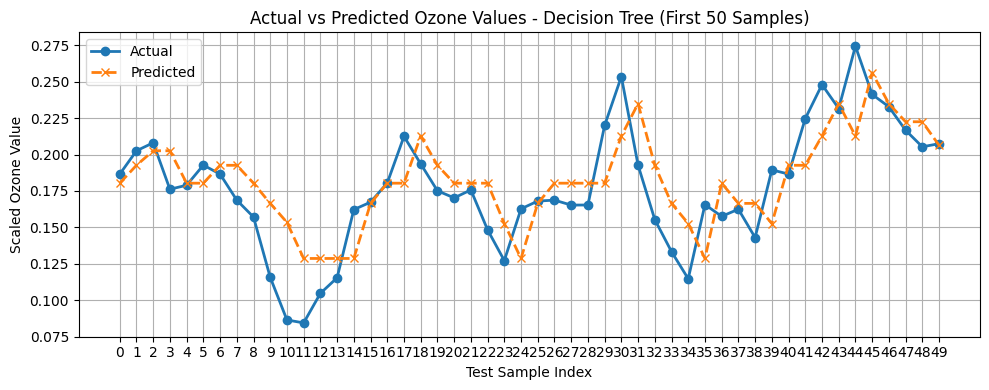

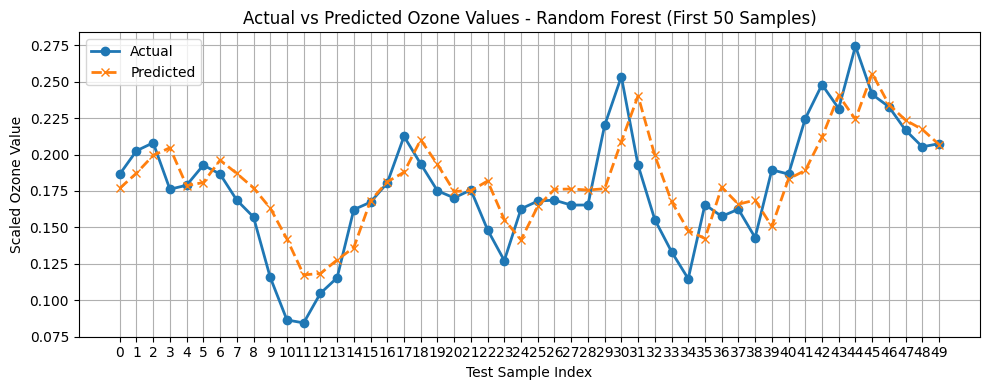

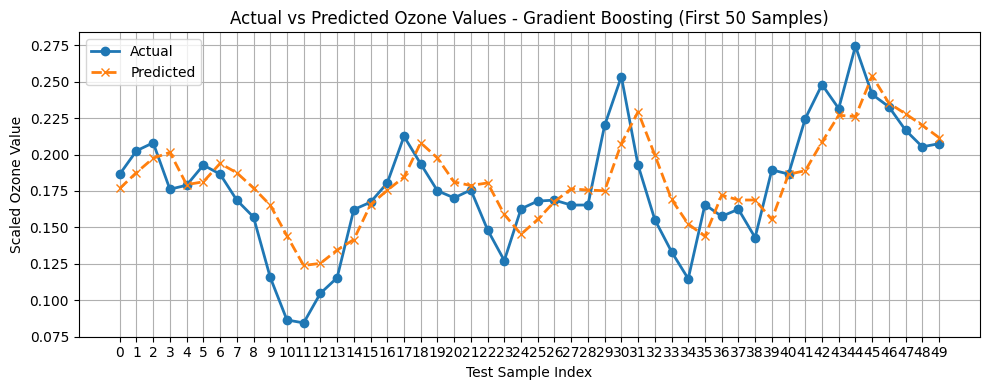

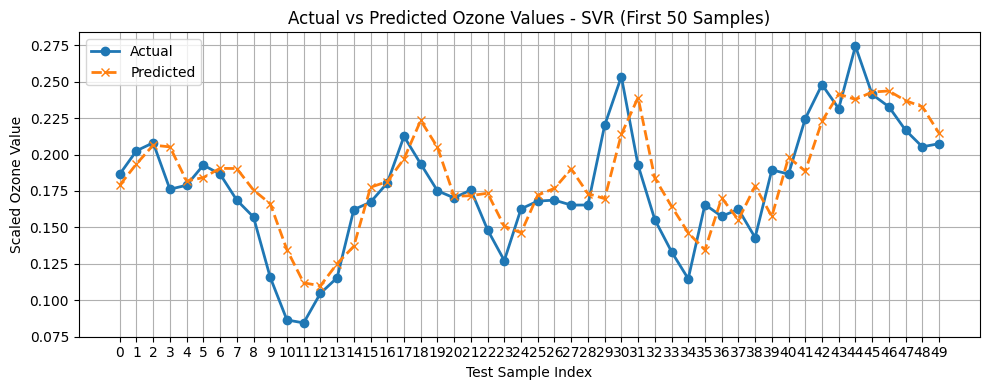

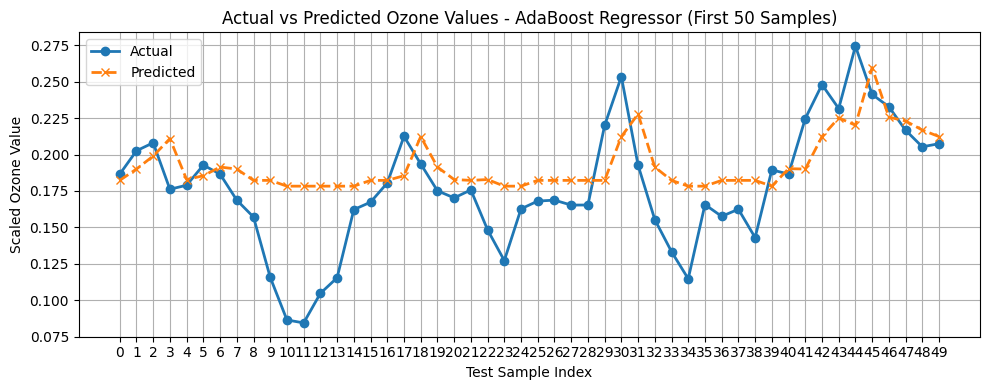

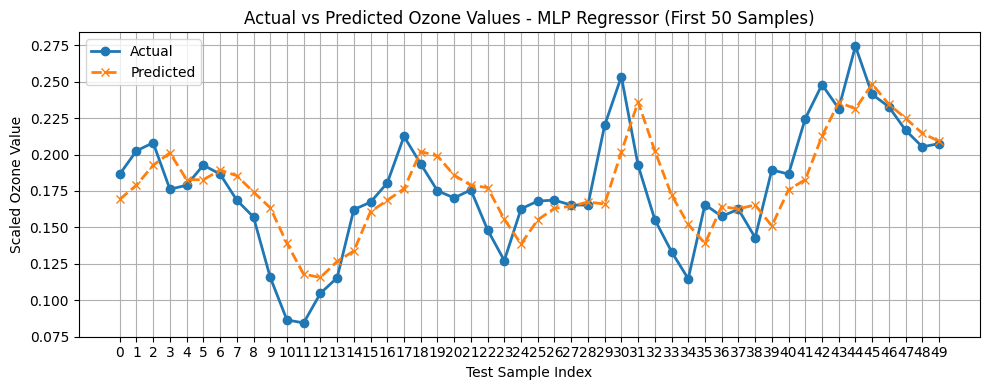

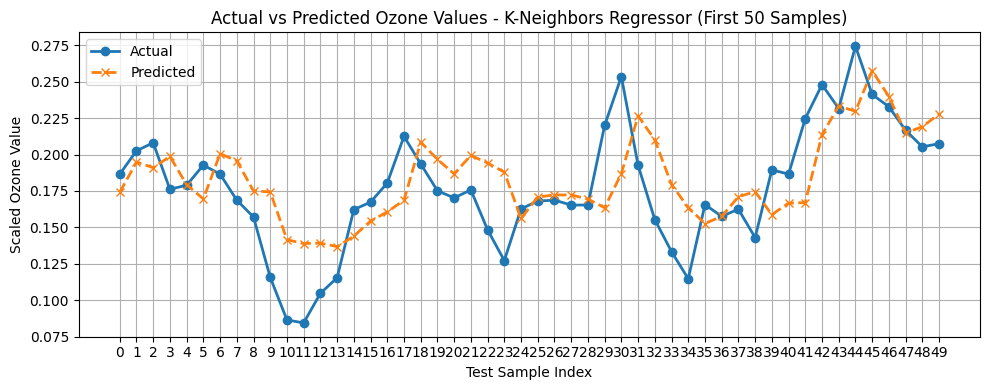

In [25]:
n_display = 50  # Only show the first 10 test samples

for name, res in results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(range(n_display), y_test[:n_display], label='Actual', linewidth=2, marker='o')
    plt.plot(range(n_display), res['Predictions'][:n_display], label='Predicted', linewidth=2, linestyle='--', marker='x')
    
    plt.title(f'Actual vs Predicted Ozone Values - {name} (First {n_display} Samples)')
    plt.xlabel('Test Sample Index')
    plt.ylabel('Scaled Ozone Value')
    plt.xticks(range(n_display))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Plotting Expected vs Predicted**

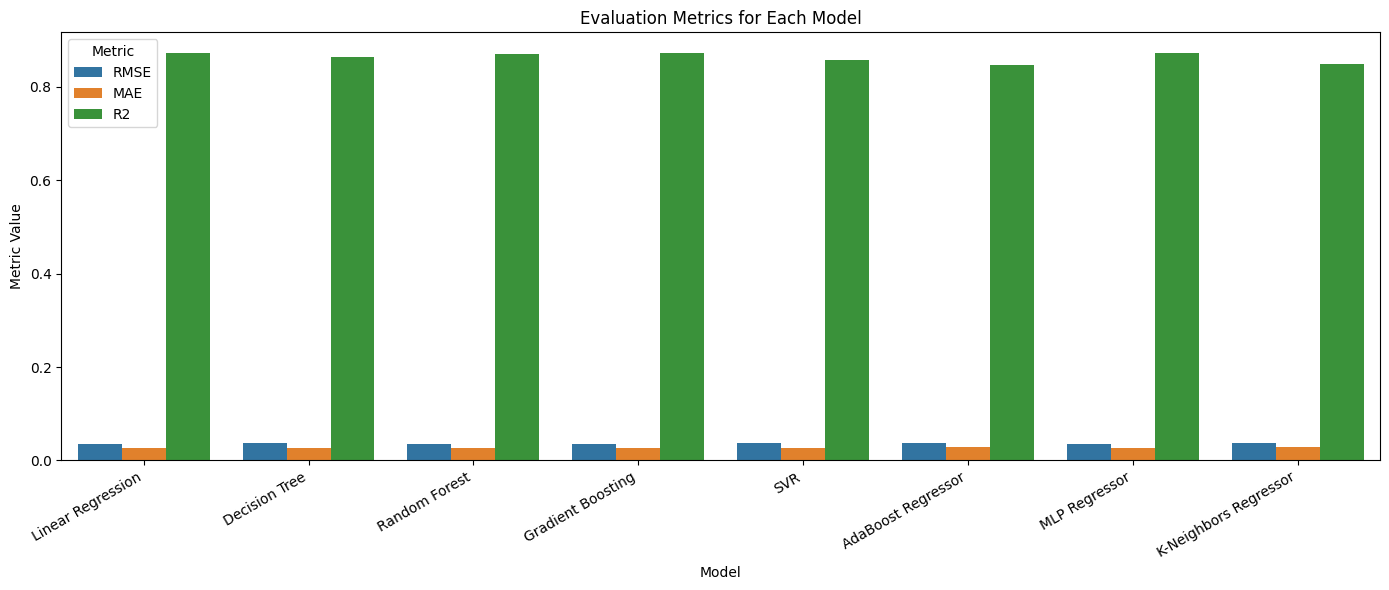

In [20]:
# Prepare data for bar chart
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [res['RMSE'] for res in results.values()],
    'MAE': [res['MAE'] for res in results.values()],
    'R2': [res['R2'] for res in results.values()]
})

plt.figure(figsize=(14, 6))
metrics_df_melted = metrics_df.melt(id_vars='Model', value_vars=['RMSE', 'MAE', 'R2'], var_name='Metric', value_name='Value')
sns.barplot(data=metrics_df_melted, x='Model', y='Value', hue='Metric')
plt.title('Evaluation Metrics for Each Model')
plt.ylabel('Metric Value')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()